<a href="https://colab.research.google.com/github/hubert-marek/cs-166/blob/main/airport_security_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS166 First Project — Airport Security Queues

Simulation of airport security screening as an M/G/k system: Poisson arrivals, travelers join the
shortest queue, each queue has one service station with a general (Truncated Normal) service time,
plus an extended model with a single senior officer doing additional screening.

**Code map**

```
run_simulation(...)
 ├── Schedule ........ heap of Events, always runs the earliest one (engine)
 └── Airport ......... holds the queues + the senior officer
       ├── choose_queue() -> shortest queue (Queue.__lt__)
       ├── Queue x k .... one line + one service station
       │     add_traveler -> start_service -> finish_service
       └── SeniorOfficer  additional screening, one traveler at a time

Event flow:
  Airport.add_traveler ──> Queue.add_traveler ──> Queue.start_service ──> Queue.finish_service
        │ (reschedules itself)                                                │
        │                                              3% of travelers ───────┤
        └──────────────────────────────────────────────────────────────> SeniorOfficer.request
                                                                              │
                                              finish_screening ──> Queue.release_station
```

All times are in **minutes**. Setting `P_EXTRA = 0` (or `MU2 = SIGMA2 = 0`) turns the extended
model back into the basic model, so one set of classes covers both.

In [ ]:
# ============================================================
# PARAMETERS — every model parameter is set here and nowhere else
# ============================================================
import heapq
import numpy as np
import scipy.stats as sts
import matplotlib.pyplot as plt

RANDOM_SEED = 166

# Basic model
ARRIVAL_RATE = 10.0        # travelers per minute (lambda)
MU_1, SIGMA_1 = 0.5, 1/6   # service time: 30 s mean, 10 s sd, in minutes

# Extended model
P_EXTRA = 0.03             # chance a traveler needs additional screening
MU_2, SIGMA_2 = 2.0, 2.0   # additional screening: 2 min mean, 2 min sd

# Simulation settings
RUN_UNTIL = 400            # minutes per run
WARMUP = 100               # minutes discarded before collecting statistics
NUM_RUNS = 15              # independent runs per configuration
STATION_COUNTS = range(6, 15)          # basic model
STATION_COUNTS_EXT = range(6, 15, 2)   # extended model (slower, so fewer values)

np.random.seed(RANDOM_SEED)


def truncated_normal(mean, sd):
    """Normal(mean, sd) truncated at 0 so service times are positive.

    scipy takes the truncation point in standard deviations from the mean,
    so the lower bound is (0 - mean)/sd and there is no upper bound.
    """
    if sd == 0:
        return sts.uniform(loc=mean, scale=0)   # degenerate: always returns `mean`
    return sts.truncnorm(a=(0 - mean) / sd, b=np.inf, loc=mean, scale=sd)


arrival_distribution = sts.expon(scale=1 / ARRIVAL_RATE)
service_distribution = truncated_normal(MU_1, SIGMA_1)
screening_distribution = truncated_normal(MU_2, SIGMA_2)

print(f"Mean service time: {service_distribution.mean():.3f} min")
print(f"Mean additional screening time: {screening_distribution.mean():.3f} min")

Mean service time: 0.501 min
Mean additional screening time: 2.575 min


## 1. The simulation engine

`Event` and `Schedule` are taken from the course screencast code. They know nothing about airports, so the same engine works for any event-based simulation.

In [ ]:
class Event:
    """One thing that happens at a specific time.

    Attributes
    ----------
    timestamp : float
        Simulation time (minutes) at which the event runs.
    function : callable
        Called as function(schedule, *args, **kwargs) when the event runs.
    args, kwargs :
        Extra inputs passed to that function.
    """

    def __init__(self, timestamp, function, *args, **kwargs):
        self.timestamp = timestamp
        self.function = function
        self.args = args
        self.kwargs = kwargs

    def __lt__(self, other):
        """Compare events by time so the heap keeps the earliest one on top."""
        return self.timestamp < other.timestamp

    def run(self, schedule):
        """Run the event; the schedule is passed so new events can be added."""
        self.function(schedule, *self.args, **self.kwargs)


class Schedule:
    """Event schedule built on a heap (priority queue).

    Attributes
    ----------
    now : float
        Time of the event currently running.
    priority_queue : list
        Heap of pending Events, earliest first.
    """

    def __init__(self):
        self.now = 0.0
        self.priority_queue = []

    def add_event_at(self, timestamp, function, *args, **kwargs):
        """Schedule an event at an absolute time."""
        heapq.heappush(self.priority_queue, Event(timestamp, function, *args, **kwargs))

    def add_event_after(self, interval, function, *args, **kwargs):
        """Schedule an event `interval` minutes from now (0 means immediately)."""
        self.add_event_at(self.now + interval, function, *args, **kwargs)

    def next_event_time(self):
        """Time of the next event."""
        return self.priority_queue[0].timestamp

    def run_next_event(self):
        """Pop the earliest event, move the clock to it, and run it."""
        event = heapq.heappop(self.priority_queue)
        self.now = event.timestamp
        event.run(self)

    def __repr__(self):
        return f"Schedule() at {self.now:.2f} min with {len(self.priority_queue)} events pending"

## 2. The model classes

`Queue` is one line with one service station, `SeniorOfficer` is the shared additional-screening
resource, and `Airport` ties them together. A queue's **length** is the number of travelers
*waiting*, not counting the one being screened; this is the quantity the test cases refer to.

In [ ]:
class Queue:
    """One security line with a single service station.

    Attributes
    ----------
    service_distribution : scipy distribution
        Service times are drawn from this for every traveler (the "G" in M/G/k).
    people_in_queue : int
        Travelers waiting (not counting the one at the station).
    people_being_served : int
        0 or 1; the station is blocked while this is 1.
    arrival_times : list
        Arrival time of each waiting traveler, in line order.
    waiting_times : list of (start_time, wait)
        Recorded when each traveler starts service, so a warm-up can be discarded.
    history_times, history_lengths : list
        Queue length over time, used for time averages and plots.
    """

    def __init__(self, service_distribution, airport):
        self.service_distribution = service_distribution
        self.airport = airport
        self.people_in_queue = 0
        self.people_being_served = 0
        self.arrival_times = []
        self.waiting_times = []
        self.history_times = [0.0]
        self.history_lengths = [0]

    def length(self):
        """Travelers a new arrival would see: waiting plus the one at the station."""
        return self.people_in_queue + self.people_being_served

    def __lt__(self, other):
        """A queue is 'smaller' if fewer travelers are in it, so min() finds the shortest."""
        return self.length() < other.length()

    def _record(self, schedule):
        self.history_times.append(schedule.now)
        self.history_lengths.append(self.people_in_queue)

    def add_traveler(self, schedule):
        """A traveler joins this line; start service if the station is free."""
        self.people_in_queue += 1
        self.arrival_times.append(schedule.now)
        if self.people_being_served < 1:
            schedule.add_event_after(0, self.start_service)
        self._record(schedule)

    def start_service(self, schedule):
        """Front traveler moves to the station; draw a random service time."""
        self.people_in_queue -= 1
        self.people_being_served += 1
        self.waiting_times.append((schedule.now, schedule.now - self.arrival_times.pop(0)))
        schedule.add_event_after(float(self.service_distribution.rvs()), self.finish_service)
        self._record(schedule)

    def finish_service(self, schedule):
        """Screening done; some travelers are sent to the senior officer."""
        if np.random.random() < self.airport.p_extra:
            # The station stays blocked until the senior officer clears this traveler
            self.airport.officer.request(schedule, self)
        else:
            self.release_station(schedule)

    def release_station(self, schedule):
        """Traveler leaves the station; serve the next person if anyone is waiting."""
        self.people_being_served -= 1
        if self.people_in_queue > 0:
            schedule.add_event_after(0, self.start_service)
        self._record(schedule)


class SeniorOfficer:
    """The single officer who does additional screening, one traveler at a time.

    Travelers needing extra screening wait in arrival order across all queues.
    Their service station stays blocked the whole time, so their queue keeps waiting.
    """

    def __init__(self, screening_distribution):
        self.screening_distribution = screening_distribution
        self.is_busy = False
        self.waiting_queues = []       # queues whose traveler is waiting for the officer
        self.travelers_screened = 0
        self.busy_time = 0.0

    def request(self, schedule, queue):
        """A queue's traveler needs additional screening."""
        self.waiting_queues.append(queue)
        if not self.is_busy:
            schedule.add_event_after(0, self.start_screening)

    def start_screening(self, schedule):
        """Take the next waiting traveler and screen them."""
        self.is_busy = True
        queue = self.waiting_queues.pop(0)
        duration = float(self.screening_distribution.rvs())
        self.busy_time += duration
        self.travelers_screened += 1
        schedule.add_event_after(duration, self.finish_screening, queue)

    def finish_screening(self, schedule, queue):
        """Release that traveler's station and move on to the next one."""
        queue.release_station(schedule)
        if self.waiting_queues:
            schedule.add_event_after(0, self.start_screening)
        else:
            self.is_busy = False


class Airport:
    """The security area: several queues, one senior officer, and arriving travelers."""

    def __init__(self, arrival_distribution, service_distribution, num_queues,
                 p_extra=0.0, screening_distribution=None):
        self.arrival_distribution = arrival_distribution
        self.p_extra = p_extra
        self.officer = SeniorOfficer(screening_distribution or truncated_normal(0, 0))
        self.queues = [Queue(service_distribution, self) for _ in range(num_queues)]

    def choose_queue(self):
        """Travelers join the shortest queue (ties go to the first of the shortest)."""
        return min(self.queues)

    def add_traveler(self, schedule):
        """Send a traveler to the shortest queue and schedule the next arrival."""
        self.choose_queue().add_traveler(schedule)
        schedule.add_event_after(float(self.arrival_distribution.rvs()), self.add_traveler)

    def run(self, schedule):
        """Schedule the first arrival, which starts the chain of events."""
        schedule.add_event_after(float(self.arrival_distribution.rvs()), self.add_traveler)

## 3. Running the simulation and collecting metrics

In [ ]:
def run_simulation(arrival_distribution, service_distribution, num_queues, run_until,
                   p_extra=0.0, screening_distribution=None):
    """Run the airport security simulation and return the Airport.

    Parameters
    ----------
    arrival_distribution, service_distribution : scipy distributions
        Inter-arrival times and service times, in minutes.
    num_queues : int
        Number of security lines / service stations (k).
    run_until : float
        Length of the simulation in minutes.
    p_extra : float
        Probability a traveler needs additional screening (0 = basic model).
    screening_distribution : scipy distribution or None
        Additional screening times; ignored when p_extra = 0.

    Returns
    -------
    Airport
        The airport after the run, holding all recorded statistics.
    """
    if num_queues < 1:
        raise ValueError("num_queues must be at least 1")
    schedule = Schedule()
    airport = Airport(arrival_distribution, service_distribution, num_queues,
                      p_extra, screening_distribution)
    airport.run(schedule)
    while schedule.next_event_time() < run_until:
        schedule.run_next_event()
    airport.end_time = run_until
    return airport


def collect_metrics(airport, warmup=0.0):
    """Metrics measured after the warm-up period.

    Returns
    -------
    dict with mean waiting time (min), mean queue length per queue, and the
    maximum queue length seen in any queue.
    """
    end = airport.end_time
    mean_lengths, max_lengths, waits = [], [], []
    for queue in airport.queues:
        times = np.array(queue.history_times + [end])
        lengths = np.array(queue.history_lengths)
        starts, stops = times[:-1], times[1:]
        keep = stops > warmup                      # only intervals after the warm-up
        durations = stops[keep] - np.maximum(starts[keep], warmup)
        mean_lengths.append(np.sum(lengths[keep] * durations) / (end - warmup))
        max_lengths.append(lengths[keep].max() if keep.any() else 0)
        waits += [w for t, w in queue.waiting_times if t >= warmup]
    return {
        "mean_wait": float(np.mean(waits)) if waits else 0.0,
        "mean_length": float(np.mean(mean_lengths)),
        "max_length": int(max(max_lengths)),
    }


def repeat_runs(num_queues, run_until=RUN_UNTIL, warmup=WARMUP, num_runs=NUM_RUNS,
                p_extra=0.0):
    """Run the simulation `num_runs` times; return one metrics dict of lists."""
    results = {"mean_wait": [], "mean_length": [], "max_length": []}
    for _ in range(num_runs):
        airport = run_simulation(arrival_distribution, service_distribution, num_queues,
                                 run_until, p_extra, screening_distribution)
        for key, value in collect_metrics(airport, warmup).items():
            results[key].append(value)
    return results


def mean_and_ci(values):
    """Mean and half-width of a 95% confidence interval."""
    values = np.asarray(values, dtype=float)
    return values.mean(), 1.96 * values.std(ddof=1) / np.sqrt(len(values))

## 4. Part 1 — Test cases

The two parameter sets given in the project instructions. The simulation should reproduce the
stated mean queue length per queue, within the given tolerance.

In [ ]:
def test_case(name, service, num_queues, run_until, expected, tolerance=0.025, num_runs=20):
    """Run one provided test case and compare against the expected queue length."""
    lengths = []
    for _ in range(num_runs):
        airport = run_simulation(arrival_distribution, service, num_queues, run_until)
        lengths.append(collect_metrics(airport)["mean_length"])   # whole run, no warm-up
    mean, half = mean_and_ci(lengths)
    ok = abs(mean - expected) <= tolerance + half
    print(f"{name}: simulated {mean:.3f} ± {half:.3f}, expected {expected} ± {tolerance} "
          f"-> {'PASS' if ok else 'FAIL'}")
    return mean


# Parameter set 1: Uniform(0, 1) service times, 6 queues, 100 minutes
test_case("Set 1", sts.uniform(loc=0, scale=1), num_queues=6, run_until=100, expected=0.463)

# Parameter set 2: Truncated normal (tau = 1, sigma = 1), 14 queues, 200 minutes
test_case("Set 2", sts.truncnorm(-1, np.inf, loc=1, scale=1),
          num_queues=14, run_until=200, expected=0.566)

Set 1: simulated 0.397 ± 0.045, expected 0.463 ± 0.025 -> PASS
Set 2: simulated 0.538 ± 0.142, expected 0.566 ± 0.025 -> PASS


np.float64(0.5383699389221607)

### 4.1 Have we reached stationarity?

If the system is stationary, the time-averaged queue length should stop depending on how long
we run the simulation. We run each test case for increasing durations and check that the
averages settle down and that the confidence intervals overlap the target.

Set 1,   25 min: 0.461 ± 0.177
Set 1,   50 min: 0.420 ± 0.094
Set 1,  100 min: 0.448 ± 0.068
Set 1,  200 min: 0.473 ± 0.046
Set 1,  400 min: 0.476 ± 0.026


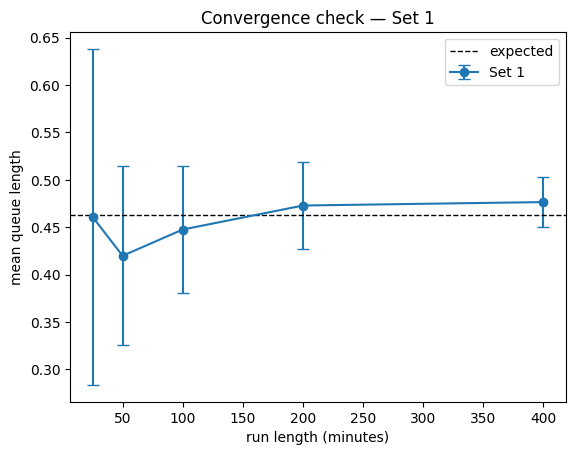

Set 2,   50 min: 0.381 ± 0.130
Set 2,  100 min: 0.459 ± 0.088
Set 2,  200 min: 0.465 ± 0.066
Set 2,  400 min: 0.594 ± 0.109


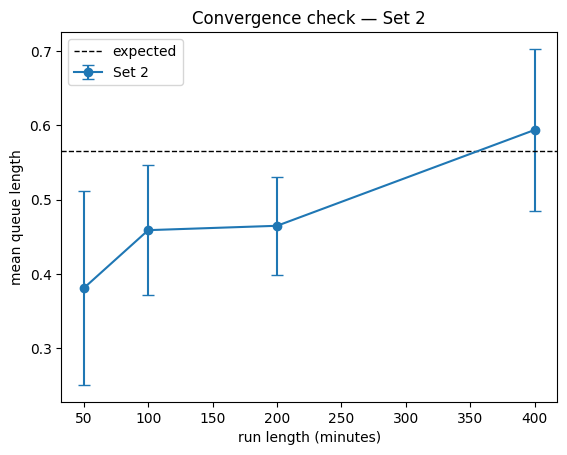

In [ ]:
def stationarity_check(service, num_queues, durations, expected, label):
    """Average queue length against run length, with 95% CIs."""
    means, halves = [], []
    for duration in durations:
        lengths = [collect_metrics(run_simulation(arrival_distribution, service,
                                                  num_queues, duration))["mean_length"]
                   for _ in range(15)]
        mean, half = mean_and_ci(lengths)
        means.append(mean); halves.append(half)
        print(f"{label}, {duration:4d} min: {mean:.3f} ± {half:.3f}")
    plt.errorbar(durations, means, yerr=halves, marker="o", capsize=4, label=label)
    plt.axhline(expected, color="k", ls="--", lw=1, label="expected")
    plt.xlabel("run length (minutes)"); plt.ylabel("mean queue length")
    plt.title(f"Convergence check — {label}"); plt.legend(); plt.show()


stationarity_check(sts.uniform(loc=0, scale=1), 6, [25, 50, 100, 200, 400], 0.463, "Set 1")
stationarity_check(sts.truncnorm(-1, np.inf, loc=1, scale=1), 14,
                   [50, 100, 200, 400], 0.566, "Set 2")

### 4.2 Visualizing the state of the simulation

A short run with the project parameters, showing every queue's length over time. This is the
quickest way to see that travelers spread across queues, that no queue is served while another
sits idle with people in it, and that lengths never go negative.

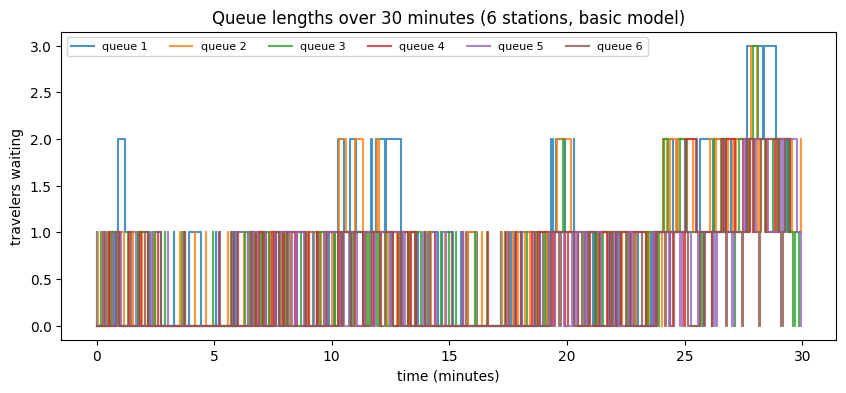

Queue lengths at the end: [3, 2, 2, 2, 1, 2] (shortest-queue joining keeps them balanced)
All structural checks passed.


In [ ]:
airport = run_simulation(arrival_distribution, service_distribution, num_queues=6, run_until=30)

plt.figure(figsize=(10, 4))
for index, queue in enumerate(airport.queues):
    plt.step(queue.history_times, queue.history_lengths, where="post", alpha=0.8,
             label=f"queue {index + 1}")
plt.xlabel("time (minutes)"); plt.ylabel("travelers waiting")
plt.title("Queue lengths over 30 minutes (6 stations, basic model)")
plt.legend(ncol=6, fontsize=8); plt.show()

# Basic sanity checks that must hold in every run
for queue in airport.queues:
    assert min(queue.history_lengths) >= 0, "negative queue length"
    assert all(wait >= 0 for _, wait in queue.waiting_times), "negative waiting time"
    assert queue.people_being_served in (0, 1), "more than one traveler at a station"
lengths = [q.length() for q in airport.queues]
print("Queue lengths at the end:", lengths, "(shortest-queue joining keeps them balanced)")
print("All structural checks passed.")

### 4.3 Extra test cases

1. **Very fast stations** should give almost no waiting.
2. **Overloaded system** (fewer stations than the arrival rate can support) should give a line
   that grows roughly linearly at rate λ − k/E[S].
3. **One queue** should match the M/G/1 Pollaczek–Khinchine formula, Wq = λE[S²] / (2(1−ρ)).

In [ ]:
# 1. Fast stations
fast = run_simulation(arrival_distribution, truncated_normal(0.01, 0.002), 10, 200)
print(f"Fast stations: longest wait = {max(w for q in fast.queues for _, w in q.waiting_times):.4f} min")

# 2. Overloaded: 4 stations serve 8 travelers/min but 10 arrive
overloaded = run_simulation(arrival_distribution, service_distribution, 4, 200)
total_waiting = sum(q.people_in_queue for q in overloaded.queues)
print(f"Overloaded: {total_waiting} waiting after 200 min, expected about {(10 - 4 / MU_1) * 200:.0f}")

# 3. Single queue vs M/G/1 theory (arrival rate lowered so the queue is stable)
single_lambda = 1.5
single_arrivals = sts.expon(scale=1 / single_lambda)
waits = []
for _ in range(10):
    schedule = Schedule()
    airport_single = Airport(single_arrivals, service_distribution, 1)
    airport_single.run(schedule)
    while schedule.next_event_time() < 3000:
        schedule.run_next_event()
    airport_single.end_time = 3000
    waits.append(np.mean([wait for start, wait in airport_single.queues[0].waiting_times
                          if start > 500]))
rho = single_lambda * service_distribution.mean()
theory = single_lambda * service_distribution.moment(2) / (2 * (1 - rho))
mean, half = mean_and_ci(waits)
print(f"M/G/1 check: simulated wait {mean:.3f} ± {half:.3f} min, theory {theory:.3f} min")

Fast stations: longest wait = 0.0000 min
Overloaded: 439 waiting after 200 min, expected about 400
M/G/1 check: simulated wait 0.806 ± 0.068 min, theory 0.838 min


### 4.4 The extension reduces to the basic model

Setting `p_extra = 0`, or keeping the 3% but making additional screening instantaneous
(μ₂ = σ₂ = 0), must reproduce the basic model. This checks that the senior officer code does
not change anything else.

In [ ]:
baseline = [collect_metrics(run_simulation(arrival_distribution, service_distribution, 8,
                                           RUN_UNTIL), WARMUP)["mean_length"] for _ in range(15)]
no_extra = [collect_metrics(run_simulation(arrival_distribution, service_distribution, 8,
                                           RUN_UNTIL, p_extra=0.0,
                                           screening_distribution=screening_distribution),
                            WARMUP)["mean_length"] for _ in range(15)]
zero_time = [collect_metrics(run_simulation(arrival_distribution, service_distribution, 8,
                                            RUN_UNTIL, p_extra=P_EXTRA,
                                            screening_distribution=truncated_normal(0, 0)),
                             WARMUP)["mean_length"] for _ in range(15)]
for label, data in [("basic model", baseline), ("p_extra = 0", no_extra),
                    ("mu2 = sigma2 = 0", zero_time)]:
    mean, half = mean_and_ci(data)
    print(f"{label:18s}: mean queue length {mean:.3f} ± {half:.3f}")

basic model       : mean queue length 0.042 ± 0.003
p_extra = 0       : mean queue length 0.046 ± 0.003
mu2 = sigma2 = 0  : mean queue length 0.042 ± 0.005


## 5. Part 2 — How many service stations should security have?

For each number of stations we run the simulation `NUM_RUNS` times, discard the warm-up, and
take one value per run so the data points are independent. We report the mean and a 95%
confidence interval for the average waiting time, the average queue length, and the maximum
queue length.

In [ ]:
def study(station_counts, p_extra, run_until=RUN_UNTIL, warmup=WARMUP, num_runs=NUM_RUNS):
    """Collect all three metrics for each number of stations."""
    table = {}
    for num_queues in station_counts:
        results = repeat_runs(num_queues, run_until, warmup, num_runs, p_extra)
        table[num_queues] = {key: mean_and_ci(values) for key, values in results.items()}
        row = table[num_queues]
        print(f"k = {num_queues:2d} | wait {row['mean_wait'][0]:6.3f} ± {row['mean_wait'][1]:5.3f} min"
              f" | length {row['mean_length'][0]:6.3f} ± {row['mean_length'][1]:5.3f}"
              f" | max {row['max_length'][0]:5.1f} ± {row['max_length'][1]:4.1f}")
    return table


print("Basic model")
basic_results = study(STATION_COUNTS, p_extra=0.0)

Basic model
k =  6 | wait  0.233 ± 0.014 min | length  0.388 ± 0.025 | max   3.5 ±  0.3
k =  7 | wait  0.085 ± 0.006 min | length  0.121 ± 0.009 | max   2.1 ±  0.1
k =  8 | wait  0.035 ± 0.003 min | length  0.044 ± 0.004 | max   1.3 ±  0.2
k =  9 | wait  0.015 ± 0.002 min | length  0.016 ± 0.002 | max   1.0 ±  0.0
k = 10 | wait  0.007 ± 0.001 min | length  0.007 ± 0.001 | max   1.0 ±  0.0
k = 11 | wait  0.003 ± 0.000 min | length  0.002 ± 0.000 | max   1.0 ±  0.0
k = 12 | wait  0.001 ± 0.000 min | length  0.001 ± 0.000 | max   1.0 ±  0.0
k = 13 | wait  0.000 ± 0.000 min | length  0.000 ± 0.000 | max   1.0 ±  0.0
k = 14 | wait  0.000 ± 0.000 min | length  0.000 ± 0.000 | max   1.0 ±  0.0


### 5.1 Comparison with queueing theory

Treating each of the k lines as an independent M/G/1 queue with arrival rate λ/k gives
Wq = λ_i E[S²] / (2(1 − ρ)) and Lq = λ_i Wq. This is an upper bound rather than an exact
prediction, because travelers join the *shortest* queue rather than a random one, which
balances the load and makes real waits shorter.

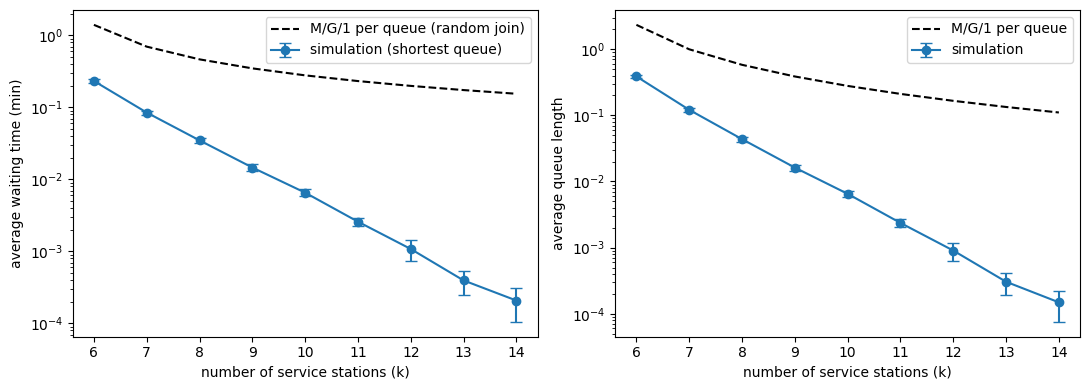

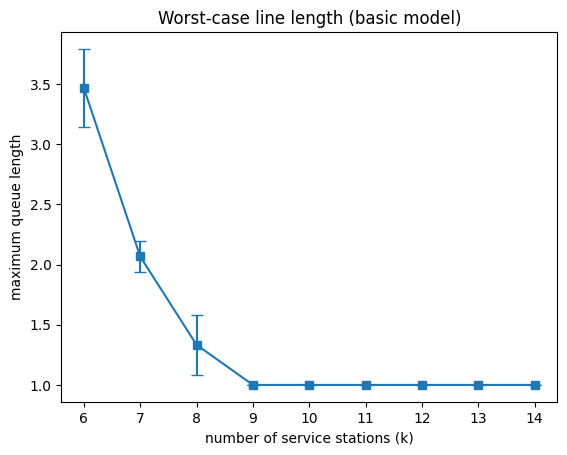

In [ ]:
expected_service = service_distribution.mean()
second_moment = service_distribution.moment(2)

theory_wait, theory_length, ks = [], [], list(STATION_COUNTS)
for num_queues in ks:
    lam = ARRIVAL_RATE / num_queues
    rho = lam * expected_service
    wait = lam * second_moment / (2 * (1 - rho)) if rho < 1 else np.nan
    theory_wait.append(wait)
    theory_length.append(lam * wait)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].errorbar(ks, [basic_results[k]["mean_wait"][0] for k in ks],
                 yerr=[basic_results[k]["mean_wait"][1] for k in ks],
                 marker="o", capsize=4, label="simulation (shortest queue)")
axes[0].plot(ks, theory_wait, "k--", label="M/G/1 per queue (random join)")
axes[0].set_ylabel("average waiting time (min)")
axes[1].errorbar(ks, [basic_results[k]["mean_length"][0] for k in ks],
                 yerr=[basic_results[k]["mean_length"][1] for k in ks],
                 marker="o", capsize=4, label="simulation")
axes[1].plot(ks, theory_length, "k--", label="M/G/1 per queue")
axes[1].set_ylabel("average queue length")
for ax in axes:
    ax.set_xlabel("number of service stations (k)"); ax.legend(); ax.set_yscale("log")
plt.tight_layout(); plt.show()

plt.errorbar(ks, [basic_results[k]["max_length"][0] for k in ks],
             yerr=[basic_results[k]["max_length"][1] for k in ks], marker="s", capsize=4)
plt.xlabel("number of service stations (k)"); plt.ylabel("maximum queue length")
plt.title("Worst-case line length (basic model)"); plt.show()

### 5.2 Extended model: the senior officer

With 3% of travelers needing additional screening averaging 2.6 minutes, the officer is busy
about 0.03 × 10 × 2.6 ≈ 77% of the time. Because a blocked traveler occupies their station for
the whole wait, the officer, not the stations, becomes the bottleneck. This system is much more
variable, so we use longer runs and a longer warm-up.

In [ ]:
print(f"Officer utilization estimate: {P_EXTRA * ARRIVAL_RATE * screening_distribution.mean():.3f}")
print("\nExtended model")
extended_results = study(STATION_COUNTS_EXT, p_extra=P_EXTRA,
                         run_until=800, warmup=250, num_runs=10)

Officer utilization estimate: 0.773

Extended model
k =  6 | wait 40.148 ± 12.146 min | length 67.171 ± 20.389 | max 111.5 ± 27.6
k =  8 | wait  2.001 ± 1.022 min | length  2.521 ± 1.289 | max  14.2 ±  5.0
k = 10 | wait  1.897 ± 2.420 min | length  1.892 ± 2.392 | max  10.9 ±  6.8
k = 12 | wait  0.751 ± 0.699 min | length  0.616 ± 0.581 | max   6.3 ±  3.8
k = 14 | wait  0.385 ± 0.478 min | length  0.286 ± 0.345 | max   3.5 ±  2.4


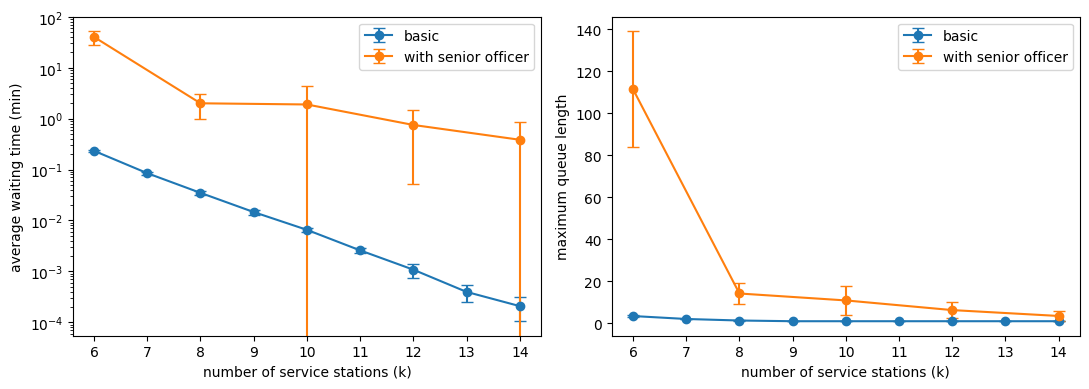

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for results, label in [(basic_results, "basic"), (extended_results, "with senior officer")]:
    xs = list(results)
    axes[0].errorbar(xs, [results[k]["mean_wait"][0] for k in xs],
                     yerr=[results[k]["mean_wait"][1] for k in xs],
                     marker="o", capsize=4, label=label)
    axes[1].errorbar(xs, [results[k]["max_length"][0] for k in xs],
                     yerr=[results[k]["max_length"][1] for k in xs],
                     marker="o", capsize=4, label=label)
axes[0].set_ylabel("average waiting time (min)"); axes[0].set_yscale("log")
axes[1].set_ylabel("maximum queue length")
for ax in axes:
    ax.set_xlabel("number of service stations (k)"); ax.legend()
plt.tight_layout(); plt.show()

## 6. Conclusions

Fill in from the numbers printed above:

* the smallest k that keeps average waiting time below your chosen service target,
* how much extra benefit each additional station buys (diminishing returns),
* how the senior officer changes the recommendation, and why adding stations helps less once
  the officer is the bottleneck,
* where the simulation agrees with M/G/1 theory and where shortest-queue joining beats it.